# Autorzy: Szymon Świeboda, Maciej Pawęzka, Karol Szymaniak
# Temat: Diagnozowanie Chorób Serca
# Zbiór danych: Heart Disease UCI

# 1. Wprowadzenie

## 1.1. Cel projektu
Celem projektu jest stworzenie modelu uczenia maszynowego, który na podstawie dostępnych parametrów medycznych będzie w stanie z wysoką skutecznością przewidzieć występowanie choroby serca u pacjentów.

## 1.2. Opis problemu biznesowego/naukowego
Choroby serca są jedną z głównych przyczyn zgonów na świecie. Wczesna diagnoza jest kluczowa dla skutecznego leczenia, jednak często wymaga skomplikowanych i kosztownych badań. Wykorzystanie algorytmów uczenia maszynowego do analizy podstawowych parametrów medycznych może wspomóc lekarzy w szybszej i wstępnej ocenie ryzyka zachorowania. Taki system wspomagania decyzji pozwala na lepszą priorytetyzację pacjentów, optymalizację ścieżki diagnostycznej oraz potencjalnie ratuje życie poprzez szybsze wykrycie zagrożenia. Projekt ten ma na celu zbadanie, które czynniki mają największy wpływ na diagnozę oraz porównanie skuteczności różnych, popularnych algorytmów klasyfikacyjnych.

# 2. Wstępna analiza danych:

In [1]:
import pandas as pd
import numpy as np

try:
    df = pd.read_csv('heart.csv')
    print("Zbiór danych został wczytany pomyślnie.")
except FileNotFoundError:
    print("Błąd: Nie znaleziono pliku 'heart.csv'. Sprawdź ścieżkę do pliku.")

Zbiór danych został wczytany pomyślnie.


## 2.1. Opis zbioru danych:

In [2]:
rows, cols = df.shape
print(f"Liczba obserwacji (wierszy): {rows}")
print(f"Liczba zmiennych (kolumn): {cols}")

print("\n---------------------- Pierwsze 5 wierszy ----------------------")
display(df.head())

Liczba obserwacji (wierszy): 1025
Liczba zmiennych (kolumn): 14

---------------------- Pierwsze 5 wierszy ----------------------


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


## 2.2. Opis zmiennych:

### Słownik danych:
- age: Wiek pacjenta (zmienna ciągła)
- sex: Płeć (1 = mężczyzna, 0 = kobieta) (zmienna kategoryczna)
- cp: Typ bólu w klatce piersiowej (0-3) (zmienna kategoryczna)
- trestbps: Spoczynkowe ciśnienie krwi (zmienna ciągła)
- chol: Poziom cholesterolu w surowicy [mg/dl] (zmienna ciągła)
- fbs: Cukier we krwi na czczo > 120 mg/dl (1 = tak, 0 = nie) (zmienna kategoryczna binarna)
- restecg: Wyniki spoczynkowego EKG (0-2) (zmienna kategoryczna)
- thalach: Maksymalne tętno (zmienna ciągła)
- exang: Dławica wysiłkowa (1 = tak, 0 = nie) (zmienna kategoryczna binarna)
- oldpeak: Obniżenie odcinka ST wywołane wysiłkiem (zmienna ciągła)
- slope: Nachylenie odcinka ST (0-2) (zmienna kategoryczna)
- ca: Liczba głównych naczyń zabarwionych we fluoroskopii (0-4) (zmienna ciągła/porządkowa)
- thal: Talasemia (0-3) (zmienna kategoryczna)
- target: Zmienna celu (1 = choroba, 0 = brak choroby)

In [3]:
print("---------------------- Typy danych ----------------------")
print(df.info())

zmienne_kat = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal', 'target']
zmienne_num = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca']

print(f"\nZmienne kategoryczne (ilość: {len(zmienne_kat)}): {zmienne_kat}")
print(f"Zmienne ciągłe/numeryczne (ilość: {len(zmienne_num)}): {zmienne_num}")

---------------------- Typy danych ----------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB
None

Zmienne kategoryczne (ilość: 8): ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal', 'target']
Zmienne ciągłe/numeryczne (ilość: 6): ['age', 'tres

## 2.3. Analiza brakujących danych i wartości odstających

In [4]:
wartosci_brak = df.isnull().sum()
print("---------------------- Brakujące wartości w kolumnach ----------------------")
print(wartosci_brak[wartosci_brak > 0])

if wartosci_brak.sum() == 0:
    print("\nBrak pustych wartości w zbiorze danych.")


print("\n---------------------- Analiza wartości odstających (Metoda IQR) ----------------------")

zmienne_ciagle = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

for col in zmienne_ciagle:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    dolna_granica = Q1 - 1.5 * IQR
    gorna_granica = Q3 + 1.5 * IQR
    
    odstajace = df[(df[col] < dolna_granica) | (df[col] > gorna_granica)]
    print(f"Cecha '{col}': liczba wartości odstających = {len(odstajace)}")

---------------------- Brakujące wartości w kolumnach ----------------------
Series([], dtype: int64)

Brak pustych wartości w zbiorze danych.

---------------------- Analiza wartości odstających (Metoda IQR) ----------------------
Cecha 'age': liczba wartości odstających = 0
Cecha 'trestbps': liczba wartości odstających = 30
Cecha 'chol': liczba wartości odstających = 16
Cecha 'thalach': liczba wartości odstających = 4
Cecha 'oldpeak': liczba wartości odstających = 7


## 2.4. Analiza statystyczna zmiennych:

In [5]:
print("---------------------- Statystyki dla zmiennych numerycznych ----------------------")
display(df[zmienne_num].describe().T)

print("\n---------------------- Analiza zmiennej celu ----------------------")
target_counts = df['target'].value_counts()
target_proportions = df['target'].value_counts(normalize=True)

print(f"Liczba chorych (1): {target_counts[1]} ({target_proportions[1]:.2%})")
print(f"Liczba zdrowych (0): {target_counts[0]} ({target_proportions[0]:.2%})")

---------------------- Statystyki dla zmiennych numerycznych ----------------------


,count,mean,std,min,25%,50%,75%,max
age,1025.0,54.434146,9.072290,29.0,48.0,56.0,61.0,77.0
trestbps,1025.0,131.611707,17.516718,94.0,120.0,130.0,140.0,200.0
chol,1025.0,246.000000,51.592510,126.0,211.0,240.0,275.0,564.0
thalach,1025.0,149.114146,23.005724,71.0,132.0,152.0,166.0,202.0
oldpeak,1025.0,1.071512,1.175053,0.0,0.0,0.8,1.8,6.2
ca,1025.0,0.754146,1.030798,0.0,0.0,0.0,1.0,4.0



---------------------- Analiza zmiennej celu ----------------------
Liczba chorych (1): 526 (51.32%)
Liczba zdrowych (0): 499 (48.68%)


## 2.5. Identyfikacja kluczowych zależności:

In [6]:
# Korelacje zmiennych:
macierz_korelacji = df.corr()

print("---------------------- Korelacja cech ze zmienną 'target' ----------------------")
korelacja_target = macierz_korelacji['target'].sort_values(ascending=False)
print(korelacja_target)

print("\n---------------------- Wnioski wstępne ----------------------")
print("Najsilniejsza korelacja dodatnia (czynniki ryzyka):")
print(korelacja_target[korelacja_target > 0.2].index.tolist())

print("\nNajsilniejsza korelacja ujemna (czynniki chroniące/odwrotne):")
print(korelacja_target[korelacja_target < -0.2].index.tolist())

---------------------- Korelacja cech ze zmienną 'target' ----------------------
target      1.000000
cp          0.434854
thalach     0.422895
slope       0.345512
restecg     0.134468
fbs        -0.041164
chol       -0.099966
trestbps   -0.138772
age        -0.229324
sex        -0.279501
thal       -0.337838
ca         -0.382085
exang      -0.438029
oldpeak    -0.438441
Name: target, dtype: float64

---------------------- Wnioski wstępne ----------------------
Najsilniejsza korelacja dodatnia (czynniki ryzyka):
['target', 'cp', 'thalach', 'slope']

Najsilniejsza korelacja ujemna (czynniki chroniące/odwrotne):
['age', 'sex', 'thal', 'ca', 'exang', 'oldpeak']


# 3. Wizualizacja danych:

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

zmienne_ciagle = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
zmienne_kategoryczne = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal', 'target']

mapa_nazw = {
    'age': 'Wiek',
    'sex': 'Płeć',
    'cp': 'Typ bólu klatki',
    'trestbps': 'Ciśnienie spoczynkowe',
    'chol': 'Cholesterol',
    'fbs': 'Cukier na czczo > 120',
    'restecg': 'EKG spoczynkowe',
    'thalach': 'Tętno maksymalne',
    'exang': 'Dławica wysiłkowa',
    'oldpeak': 'Obniżenie ST',
    'slope': 'Nachylenie ST',
    'ca': 'Liczba naczyń',
    'thal': 'Talasemia',
    'target': 'Diagnoza',
    'wysokie_cisnienie': 'Wysokie ciśnienie'
}

## 3.1. Rozkłady zmiennych ciągłych

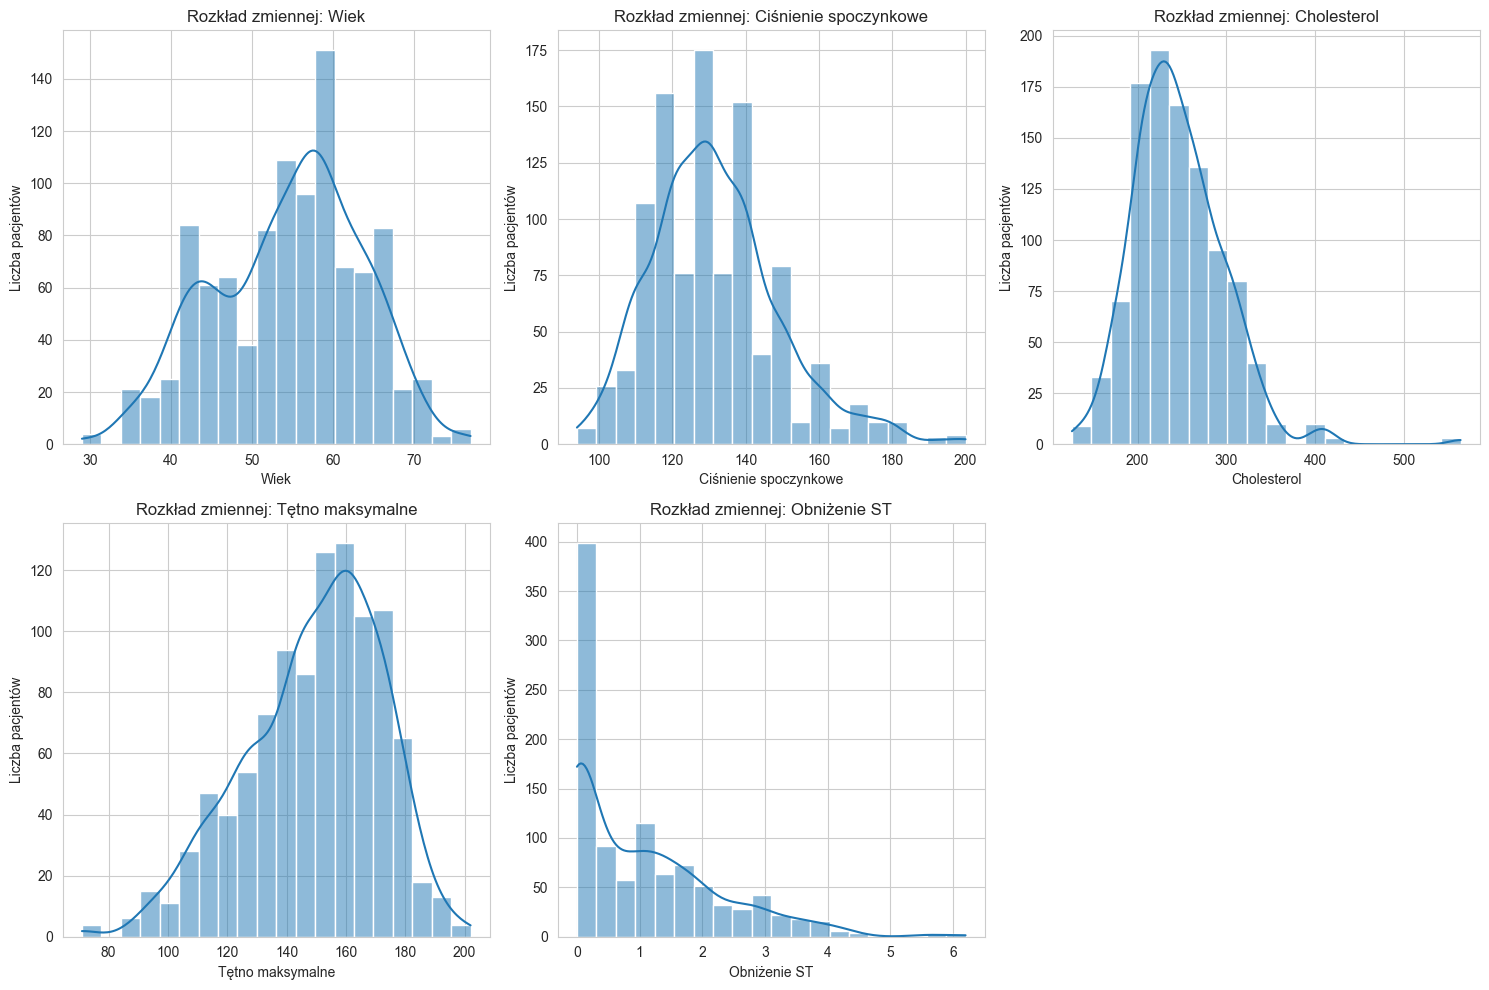

In [8]:
plt.figure(figsize=(15, 10))

for numer, kolumna in enumerate(zmienne_ciagle, 1):
    plt.subplot(2, 3, numer)
    sns.histplot(df[kolumna], kde=True, bins=20)
    
    nazwa = mapa_nazw.get(kolumna, kolumna)
    plt.title(f'Rozkład zmiennej: {nazwa}')
    plt.xlabel(nazwa)
    plt.ylabel('Liczba pacjentów')

plt.tight_layout()
plt.show()

## 3.2. Rozkłady zmiennych kategorycznych

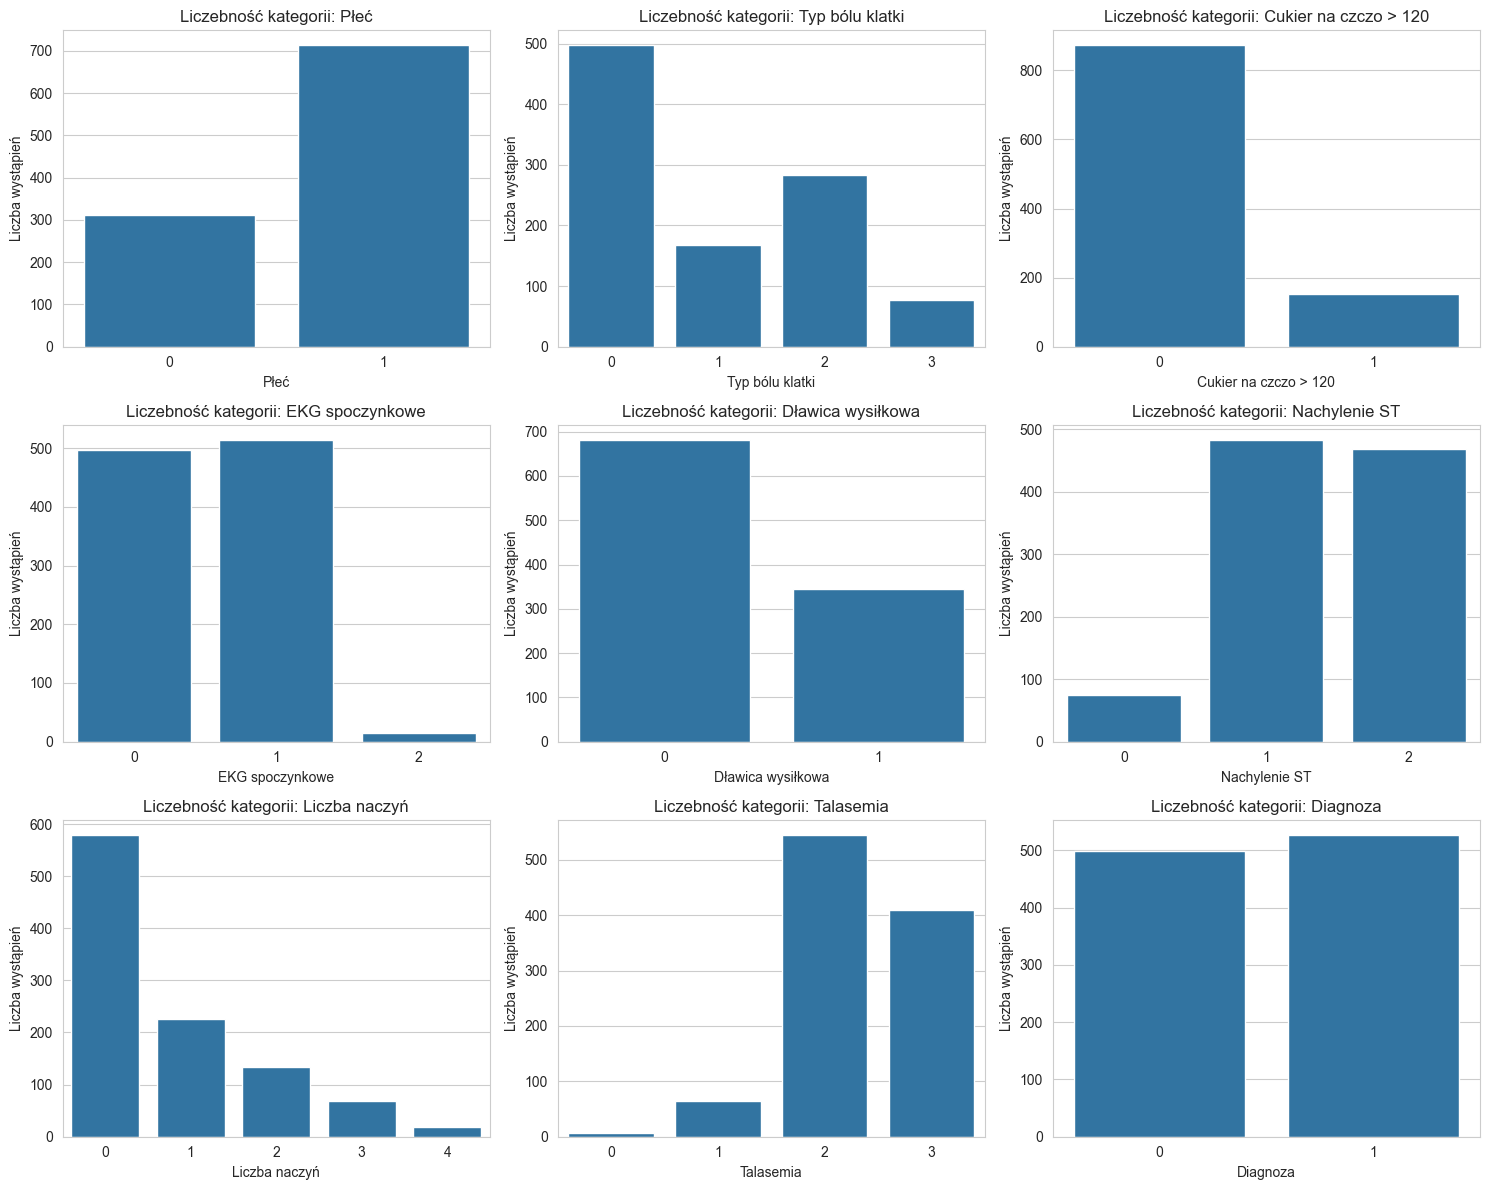

In [9]:
plt.figure(figsize=(15, 12))

for numer, kolumna in enumerate(zmienne_kategoryczne, 1):
    plt.subplot(3, 3, numer)
    sns.countplot(x=kolumna, data=df)
    
    nazwa = mapa_nazw.get(kolumna, kolumna)
    plt.title(f'Liczebność kategorii: {nazwa}')
    plt.xlabel(nazwa)
    plt.ylabel('Liczba wystąpień')

plt.tight_layout()
plt.show()

## 3.3. Wykresy zależności między zmiennymi objaśniającymi a docelowymi

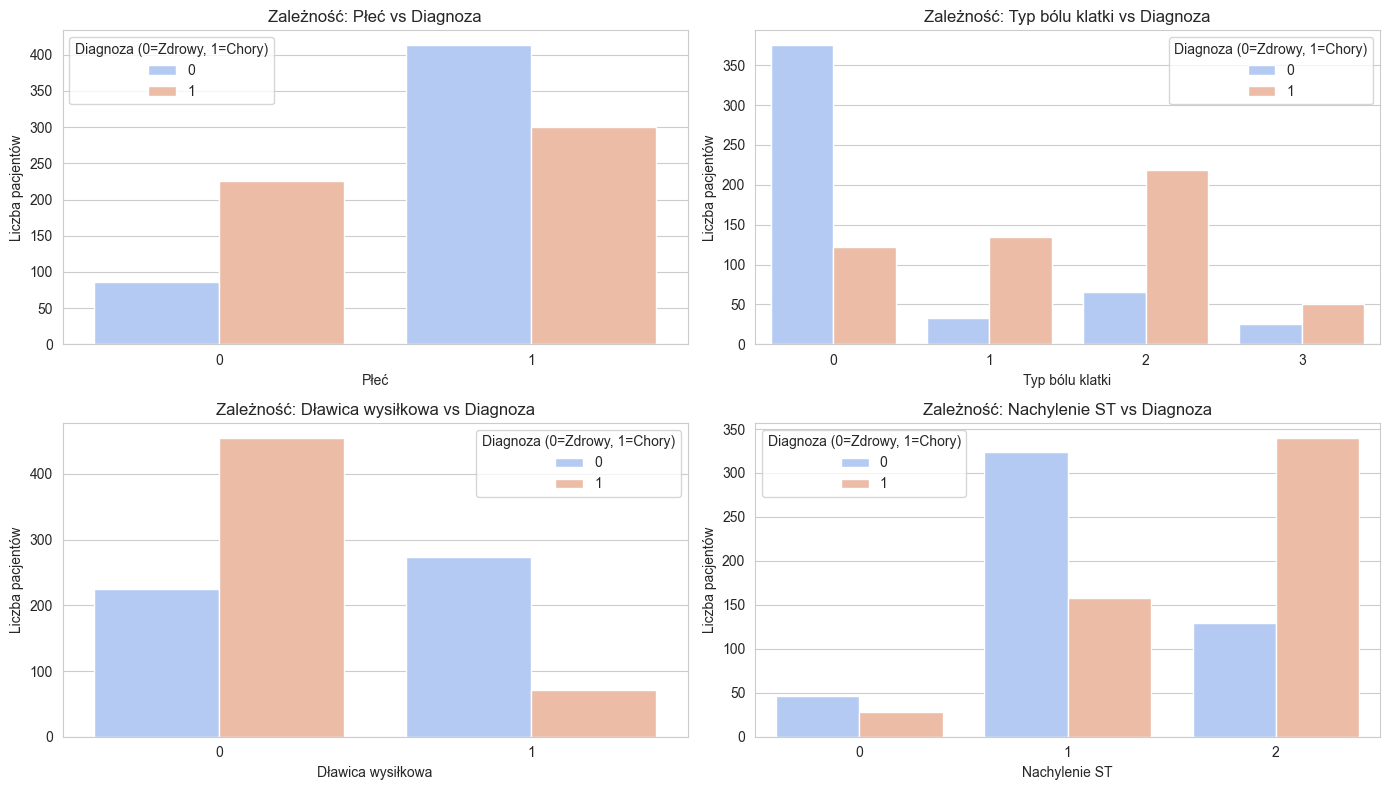

In [10]:
cechy_do_analizy = ['sex', 'cp', 'exang', 'slope']

plt.figure(figsize=(14, 8))

for numer, kolumna in enumerate(cechy_do_analizy, 1):
    plt.subplot(2, 2, numer)
    
    sns.countplot(x=kolumna, hue='target', data=df, palette='coolwarm')
    
    nazwa = mapa_nazw.get(kolumna, kolumna)
    plt.title(f'Zależność: {nazwa} vs Diagnoza')
    plt.xlabel(nazwa)
    plt.ylabel('Liczba pacjentów')
    plt.legend(title='Diagnoza (0=Zdrowy, 1=Chory)')

plt.tight_layout()
plt.show()

## 3.4. Macierz korelacji
- Kolory ciepłe (czerwony) oznaczają korelację dodatnią.
- Kolory zimne (niebieski) oznaczają korelację ujemną.

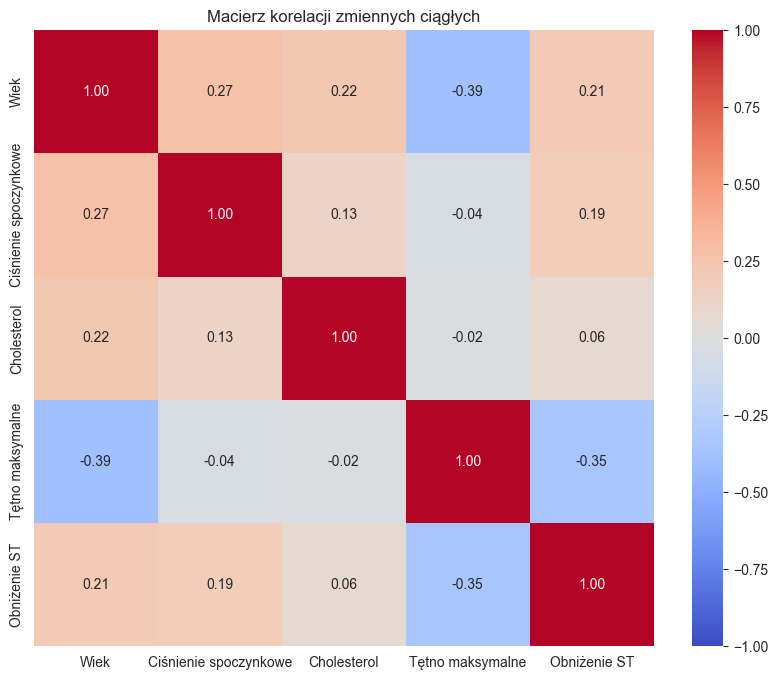

In [11]:
plt.figure(figsize=(10, 8))


macierz_korelacji = df[zmienne_ciagle].corr()


korelacja_etykiety = macierz_korelacji.rename(columns=mapa_nazw, index=mapa_nazw)

sns.heatmap(korelacja_etykiety, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)

plt.title('Macierz korelacji zmiennych ciągłych')
plt.show()

## 3.5. Wykresy pudełkowe dla analizy zmiennych kategorycznych

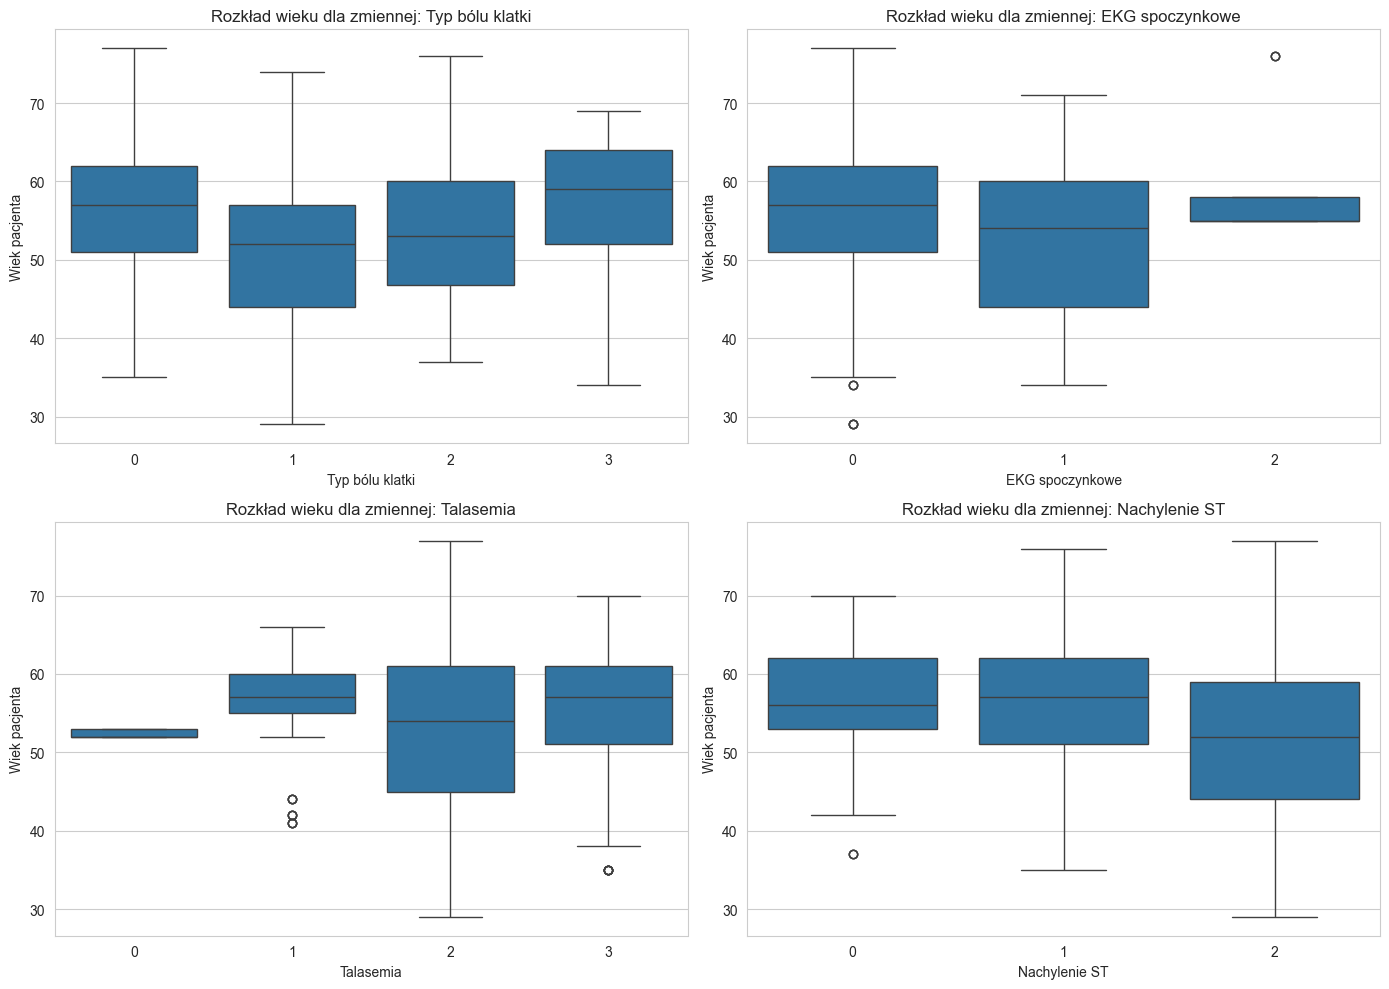

In [12]:
lista_kategorii = ['cp', 'restecg', 'thal', 'slope']

plt.figure(figsize=(14, 10))

for numer, kolumna in enumerate(lista_kategorii, 1):
    plt.subplot(2, 2, numer)
    
    nazwa = mapa_nazw.get(kolumna, kolumna)
    sns.boxplot(x=kolumna, y='age', data=df)
    
    plt.title(f'Rozkład wieku dla zmiennej: {nazwa}')
    plt.xlabel(nazwa)
    plt.ylabel('Wiek pacjenta')

plt.tight_layout()
plt.show()

## 3.6. Podsumowanie i wnioski z analizy wizualnej

1.  **Rozkłady zmiennych:**
    *   Większość zmiennych kategorycznych nie jest równomiernie rozłożona.
    *   Zmienna age ma rozkład zbliżony do normalnego, co widać na histogramie.
    *   Zmienne chol (cholesterol) i trestbps (ciśnienie) mają widoczną asymetrię prawostronną, co oznacza występowanie wysokich wartości odstających.

2.  **Zależności z cechą docelową (Target):**
    *   Najsilniejszą zależność widać przy zmiennej cp (ból klatki). Pacjenci z typem bólu 0 rzadziej są chorzy, natomiast przy typach 1, 2 i 3 liczba chorych znacznie rośnie.
    *   Podobnie zmienna exang (dławica) – brak dławicy wysiłkowej (wartość 0) jest częstszy u osób zdiagnozowanych jako chore w tym zbiorze.

3.  **Korelacje:**
    *   Macierz korelacji dla zmiennych ciągłych pokazuje, że nie są one ze sobą mocno powiązane. Największa korelacja (ujemna) występuje między wiekiem (age) a tętnem (thalach) co jest naturalne.
    *   Brak silnych korelacji między zmiennymi objaśniającymi (np. ciśnienie a cholesterol) jest korzystny, ponieważ każda zmienna wnosi unikalną wiedzę do modelu.

4.  **Analiza zmiennych kategorycznych:**
    *   Wykresy pudełkowe pokazują, że wiek pacjentów jest dość podobny w różnych grupach. Na przykład dla zmiennej cp (ból klatki) mediany wieku są zbliżone, co sugeruje, że typ bólu nie zależy drastycznie od wieku pacjenta.

# 4. Przetwarzanie danych
W tym etapie przygotujemy dane do modelowania. Zgodnie z wnioskami z poprzednich etapów oraz wymaganiami projektu, wykonamy:
1. Czyszczenie danych (usunięcie duplikatów).
2. Inżynierię cech (Feature Engineering) - stworzenie nowych zmiennych.
3. Selekcję zmiennych (usunięcie cech o niskiej korelacji).
4. Podział na zbiór treningowy i testowy.
5. Budowę Pipeline'u przetwarzającego (skalowanie i kodowanie).

## 4.1. Czyszczenie danych
Ponieważ nie ma brakujących wartości (NaN), czyszczenie ograniczy się do usunięcia powtarzających się wierszy, aby nie zafałszowały wyników modelu.

In [13]:
print(f"Rozmiar zbioru przed czyszczeniem: {df.shape}")

df = df.drop_duplicates()

print(f"Rozmiar zbioru po usunięciu duplikatów: {df.shape}")

df = df.reset_index(drop=True)
print("Duplikaty zostały usunięte.")

Rozmiar zbioru przed czyszczeniem: (1025, 14)
Rozmiar zbioru po usunięciu duplikatów: (302, 14)
Duplikaty zostały usunięte.


# 4.2. Feature Engineering 
Tworzymy nową zmienną, która może pomóc modelowi w lepszej klasyfikacji. Na podstawie wiedzy ogólnej, wysokie ciśnienie krwi jest czynnikiem ryzyka. Stworzymy prostą zmienną kategoryczną dzielącą ciśnienie na "Norma" i "Wysokie".

In [14]:
# Jeśli trestbps > 140 to 1 (Wysokie), w przeciwnym razie 0 (Norma)
df['wysokie_cisnienie'] = df['trestbps'].apply(lambda x: 1 if x > 140 else 0)

print("Dodano nową cechę: 'wysokie_cisnienie'.")
print(df[['trestbps', 'wysokie_cisnienie']].head())

Dodano nową cechę: 'wysokie_cisnienie'.
   trestbps  wysokie_cisnienie
0       125                  0
1       140                  0
2       145                  1
3       148                  1
4       138                  0


# 4.3. Wybór zmiennych
W analizie korelacji zauważyliśmy, że zmienna fbs (cukier na czczo) ma bardzo niską korelację ze zmienną celu (-0.04). Zmienna ta wnosi mało informacji, dlatego decydujemy się ją usunąć, aby uprościć model.

In [15]:
zmienne_do_usuniecia = ['fbs']
df_po_selecji = df.drop(columns=zmienne_do_usuniecia)

print(f"Usunięto kolumny: {zmienne_do_usuniecia}")
print(f"Aktualne kolumny: {df_po_selecji.columns.tolist()}")

Usunięto kolumny: ['fbs']
Aktualne kolumny: ['age', 'sex', 'cp', 'trestbps', 'chol', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target', 'wysokie_cisnienie']


# 4.4. Podział na zbiór treningowy i testowy
Dzielimy dane na:
- X: zmienne objaśniające (wszystko oprócz target)
- y: zmienna celu (target)
Stosujemy podział 80% (trening) do 20% (test). Używamy parametru stratify=y, aby w obu zbiorach zachować taki sam procent osób chorych i zdrowych.

In [16]:
from sklearn.model_selection import train_test_split

X = df_po_selecji.drop('target', axis=1)
y = df_po_selecji['target']

# Podział na zbiór treningowy i testowy
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Rozmiar zbioru treningowego (X_train): {X_train.shape}")
print(f"Rozmiar zbioru testowego (X_test): {X_test.shape}")

Rozmiar zbioru treningowego (X_train): (241, 13)
Rozmiar zbioru testowego (X_test): (61, 13)


# 4.5. Konfiguracja Pipeline'u (Kodowanie i Skalowanie)
Zgodnie z najlepszymi praktykami, kodowanie zmiennych oraz skalowanie realizujemy za pomocą Pipeline, aby uniknąć wycieku danych i zapewnić powtarzalność procesu.
1. **Kodowanie zmiennych kategorycznych**: Zamieniamy kategorie na kolumny binarne.
2. **Skalowanie i normalizacja**: Stosujemy StandardScaler do normalizacji zmiennych numerycznych.

In [17]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Definicja zmiennych do przetworzenia
kolumny_numeryczne = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca']
kolumny_kategoryczne = ['sex', 'cp', 'restecg', 'exang', 'slope', 'thal', 'wysokie_cisnienie']

num_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

cat_transformer = Pipeline(steps=[
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, kolumny_numeryczne),
        ('cat', cat_transformer, kolumny_kategoryczne)
    ])


# 4.6. Weryfikacja przetwarzania
Sprawdzamy, jak wyglądają dane po przejściu przez nasz pipeline.

In [18]:
# Dopasowanie preprocessora do danych treningowych i transformacja
X_train_przetworzone = preprocessor.fit_transform(X_train)

print(f"Kształt danych przed pipeline: {X_train.shape}")
print(f"Kształt danych po pipeline (OneHotEncoding zwiększył liczbę kolumn): {X_train_przetworzone.shape}")


Kształt danych przed pipeline: (241, 13)
Kształt danych po pipeline (OneHotEncoding zwiększył liczbę kolumn): (241, 26)


# 5. Budowa modelu

## 5.1. Wybór i uzasadnienie wybranych modeli

Wybraliśmy 3 popularne modele dla problemu klasyfikacji:

**1. Logistic Regression (Regresja Logistyczna)**
- Uzasadnienie: Prosty, szybki, dobra interpretacja wyników
- Użycie: Baseline model, do porównania

**2. Random Forest (Las Losowy)**
- Uzasadnienie: Obsługuje cechy kategoryczne i numeryczne, odporny na outliers, dobrze generalizuje

**3. Support Vector Machine (SVM)**
- Uzasadnienie: Skuteczny w wielowymiarowych danych, powinien działać dobrze z pipeline'em

## 5.2. Trenowanie modeli

In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import time

models = {}
results = {}

print("1. REGRESJA LOGISTYCZNA (LOGISTIC REGRESSION)")
start_time = time.time()
model_lr = LogisticRegression(max_iter=1000, random_state=42)
model_lr.fit(X_train_przetworzone, y_train)
y_pred_lr = model_lr.predict(preprocessor.transform(X_test))
train_time_lr = time.time() - start_time

models['Log Reg'] = model_lr
results['Log Reg'] = y_pred_lr

acc_lr = accuracy_score(y_test, y_pred_lr)
print(f"   Czas trenowania: {train_time_lr:.4f} sekund")
print(f"   Dokładność (Accuracy): {acc_lr:.4f}\n")

print("2. LAS LOSOWY (RANDOM FOREST)")
start_time = time.time()
model_rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
model_rf.fit(X_train_przetworzone, y_train)
y_pred_rf = model_rf.predict(preprocessor.transform(X_test))
train_time_rf = time.time() - start_time

models['Random Forest'] = model_rf
results['Random Forest'] = y_pred_rf

acc_rf = accuracy_score(y_test, y_pred_rf)
print(f"   Czas trenowania: {train_time_rf:.4f} sekund")
print(f"   Dokładność (Accuracy): {acc_rf:.4f}\n")

print("3. MASZYNA WEKTORÓW NOŚNYCH (SVM)")
start_time = time.time()
model_svm = SVC(kernel='rbf', random_state=42)
model_svm.fit(X_train_przetworzone, y_train)
y_pred_svm = model_svm.predict(preprocessor.transform(X_test))
train_time_svm = time.time() - start_time

models['SVM'] = model_svm
results['SVM'] = y_pred_svm

acc_svm = accuracy_score(y_test, y_pred_svm)
print(f"   Czas trenowania: {train_time_svm:.4f} sekund")
print(f"   Dokładność (Accuracy): {acc_svm:.4f}\n")


1. REGRESJA LOGISTYCZNA (LOGISTIC REGRESSION)
   Czas trenowania: 0.0074 sekund
   Dokładność (Accuracy): 0.8525

2. LAS LOSOWY (RANDOM FOREST)
   Czas trenowania: 0.1249 sekund
   Dokładność (Accuracy): 0.8033

3. MASZYNA WEKTORÓW NOŚNYCH (SVM)
   Czas trenowania: 0.0040 sekund
   Dokładność (Accuracy): 0.7869



## 5.3. Porównanie modeli na zbiorze testowym

In [20]:
# Obliczenie metryk dla kazdego modelu
comparison_data = []

for model_name, y_pred in results.items():
    acc = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    comparison_data.append({
        'Model': model_name,
        'Accuracy': acc,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1
    })

comparison_df = pd.DataFrame(comparison_data)
print("TABELA POROWNAWCZA MODELI:")
print(comparison_df.to_string(index=False))

best_model_idx = comparison_df['F1-Score'].idxmax()
best_model_name = comparison_df.loc[best_model_idx, 'Model']
best_model_f1 = comparison_df.loc[best_model_idx, 'F1-Score']

print(f"\nNAJLEPSZY MODEL: {best_model_name} (F1-Score: {best_model_f1:.4f})")

TABELA POROWNAWCZA MODELI:
        Model  Accuracy  Precision   Recall  F1-Score
      Log Reg  0.852459   0.875000 0.848485  0.861538
Random Forest  0.803279   0.818182 0.818182  0.818182
          SVM  0.786885   0.812500 0.787879  0.800000

NAJLEPSZY MODEL: Log Reg (F1-Score: 0.8615)


## 5.4. Optymalizacja hiperparametrów

In [21]:
from sklearn.model_selection import GridSearchCV

print("Szukamy najlepszych parametrów: n_estimators, max_depth\n")

# Definiujemy siatkę parametrów do przeszukania
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5]
}

start_time = time.time()
grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid,
    cv=5,  
    scoring='f1',
    n_jobs=-1
)

grid_search.fit(X_train_przetworzone, y_train)
tuning_time = time.time() - start_time

print(f"Czas optymalizacji: {tuning_time:.2f} sekund\n")

best_params = grid_search.best_params_
print("Najlepsze znalezione parametry:")
for param, value in best_params.items():
    print(f"  - {param}: {value}")

print(f"\nNajlepszy wynik CV (F1-Score): {grid_search.best_score_:.4f}\n")

model_rf_optimized = RandomForestClassifier(**best_params, random_state=42, n_jobs=-1)
model_rf_optimized.fit(X_train_przetworzone, y_train)

y_pred_rf_opt = model_rf_optimized.predict(preprocessor.transform(X_test))

acc_rf_before = accuracy_score(y_test, results['Random Forest'])
acc_rf_after = accuracy_score(y_test, y_pred_rf_opt)
f1_rf_before = f1_score(y_test, results['Random Forest'])
f1_rf_after = f1_score(y_test, y_pred_rf_opt)

print("\nWYNIKI PRZED I PO OPTYMALIZACJI:")
print(f"{'Metryka':<20} {'Przed':<15} {'Po':<15} {'Zmiana':<15}")
print(f"{'Accuracy':<20} {acc_rf_before:<15.4f} {acc_rf_after:<15.4f} {acc_rf_after-acc_rf_before:+.4f}")
print(f"{'F1-Score':<20} {f1_rf_before:<15.4f} {f1_rf_after:<15.4f} {f1_rf_after-f1_rf_before:+.4f}")

Szukamy najlepszych parametrów: n_estimators, max_depth

Czas optymalizacji: 2.84 sekund

Najlepsze znalezione parametry:
  - max_depth: 10
  - min_samples_split: 5
  - n_estimators: 100

Najlepszy wynik CV (F1-Score): 0.8529


WYNIKI PRZED I PO OPTYMALIZACJI:
Metryka              Przed           Po              Zmiana         
Accuracy             0.8033          0.7705          -0.0328
F1-Score             0.8182          0.7941          -0.0241


## 5.5. Ocena jakości modeli

MODEL: Las Losowy

1. RAPORT KLASYFIKACJI
                  precision    recall  f1-score   support

Brak choroby (0)       0.77      0.71      0.74        28
     Choroba (1)       0.77      0.82      0.79        33

        accuracy                           0.77        61
       macro avg       0.77      0.77      0.77        61
    weighted avg       0.77      0.77      0.77        61

2. MACIERZ POMYŁEK
   True Negatives (TN):  20
   False Positives (FP): 8
   False Negatives (FN): 6
   True Positives (TP):  27

3. METRYKI NA ZBIORZE TESTOWYM
   Accuracy (Dokładność):    0.7705 (77.05%)
   Precision (Precyzja):     0.7714
   Recall (Czułość):         0.8182
   F1-Score:                 0.7941
   ROC-AUC Score:            0.8864


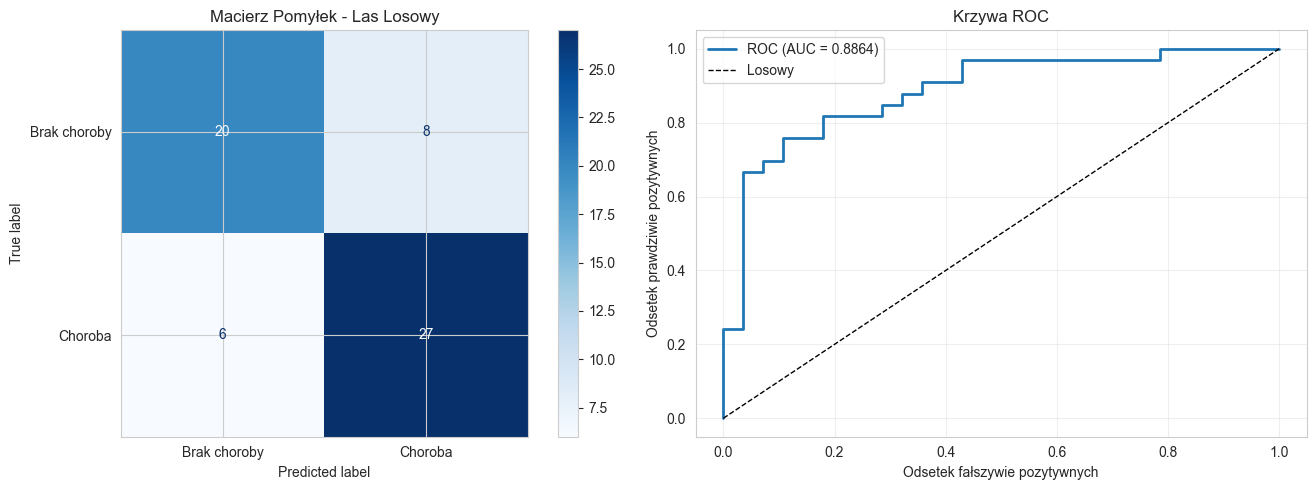

In [22]:
from sklearn.metrics import roc_curve, auc, roc_auc_score
import matplotlib.pyplot as plt

best_model = model_rf_optimized
y_pred_best = y_pred_rf_opt

print("MODEL: Las Losowy\n")

print("1. RAPORT KLASYFIKACJI")
print(classification_report(y_test, y_pred_best, target_names=['Brak choroby (0)', 'Choroba (1)']))

print("2. MACIERZ POMYŁEK")
cm = confusion_matrix(y_test, y_pred_best)
print(f"   True Negatives (TN):  {cm[0, 0]}")
print(f"   False Positives (FP): {cm[0, 1]}")
print(f"   False Negatives (FN): {cm[1, 0]}")
print(f"   True Positives (TP):  {cm[1, 1]}")

print("\n3. METRYKI NA ZBIORZE TESTOWYM")
acc_final = accuracy_score(y_test, y_pred_best)
precision_final = precision_score(y_test, y_pred_best)
recall_final = recall_score(y_test, y_pred_best)
f1_final = f1_score(y_test, y_pred_best)

print(f"   Accuracy (Dokładność):    {acc_final:.4f} ({acc_final*100:.2f}%)")
print(f"   Precision (Precyzja):     {precision_final:.4f}")
print(f"   Recall (Czułość):         {recall_final:.4f}")
print(f"   F1-Score:                 {f1_final:.4f}")

roc_auc = roc_auc_score(y_test, model_rf_optimized.predict_proba(preprocessor.transform(X_test))[:, 1])
print(f"   ROC-AUC Score:            {roc_auc:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay(cm, display_labels=['Brak choroby', 'Choroba']).plot(ax=axes[0], cmap='Blues')
axes[0].set_title('Macierz Pomyłek - Las Losowy')

fpr, tpr, _ = roc_curve(y_test, model_rf_optimized.predict_proba(preprocessor.transform(X_test))[:, 1])
axes[1].plot(fpr, tpr, label=f'ROC (AUC = {roc_auc:.4f})', linewidth=2)
axes[1].plot([0, 1], [0, 1], 'k--', label='Losowy', linewidth=1)
axes[1].set_xlabel('Odsetek fałszywie pozytywnych')
axes[1].set_ylabel('Odsetek prawdziwie pozytywnych')
axes[1].set_title('Krzywa ROC')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 6. Wyniki i wnioski

## 6.1. Podsumowanie wyników

In [23]:
print("DANE:")
print(f"  - Liczba obserwacji: {len(df)}")
print(f"  - Liczba zmiennych: {df.shape[1]}")
print(f"  - Brakujące wartości: {df.isnull().sum().sum()}")
print(f"  - Rozkład klas: {y.value_counts()[1]} chorych ({y.value_counts()[1]/len(y)*100:.1f}%) vs {y.value_counts()[0]} zdrowych ({y.value_counts()[0]/len(y)*100:.1f}%)")

print("\nPODZIAŁ DANYCH:")
print(f"  - Zbiór treningowy: {len(X_train)} obserwacji ({len(X_train)/len(X)*100:.1f}%)")
print(f"  - Zbiór testowy: {len(X_test)} obserwacji ({len(X_test)/len(X)*100:.1f}%)")

print("\nWYNIKI MODELI:")
print(f"{'Model':<25} {'Accuracy':<15} {'Precision':<15} {'F1-Score':<15}")

best_f1_global = 0
best_model_global = ""
best_metrics = {}

for model_name, y_pred in results.items():
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    nazwa_modelu = model_name
    if 'Log' in model_name: nazwa_modelu = 'Regresja Logistyczna'
    elif 'Random' in model_name: nazwa_modelu = 'Las Losowy'
    elif 'SVM' in model_name: nazwa_modelu = 'SVM'
        
    print(f"{nazwa_modelu:<25} {acc:<15.4f} {prec:<15.4f} {f1:<15.4f}")
    
    if f1 > best_f1_global:
        best_f1_global = f1
        best_model_global = nazwa_modelu
        best_metrics = {'acc': acc, 'prec': prec, 'rec': recall_score(y_test, y_pred), 'f1': f1}

if 'model_rf_optimized' in locals():
    acc_opt = accuracy_score(y_test, y_pred_rf_opt)
    prec_opt = precision_score(y_test, y_pred_rf_opt)
    f1_opt = f1_score(y_test, y_pred_rf_opt)
    rec_opt = recall_score(y_test, y_pred_rf_opt)
    
    print(f"{'Las Losowy (Opt)':<25} {acc_opt:<15.4f} {prec_opt:<15.4f} {f1_opt:<15.4f}")
    
    if f1_opt > best_f1_global:
        best_f1_global = f1_opt
        best_model_global = 'Las Losowy (Opt)'
        best_metrics = {'acc': acc_opt, 'prec': prec_opt, 'rec': rec_opt, 'f1': f1_opt}


print(f"\nNAJLEPSZY MODEL: {best_model_global}")
print(f"  - Dokładność: {best_metrics['acc']*100:.2f}%")
print(f"  - Precyzja: {best_metrics['prec']:.4f}")
print(f"  - Czułość (Recall): {best_metrics['rec']:.4f}")
print(f"  - F1-Score: {best_metrics['f1']:.4f}")

if 'Las Losowy' in best_model_global:
    print("\nOPTYMALNE HIPERPARAMETRY (Las Losowy):")
    for param, value in best_params.items():
        print(f"  - {param}: {value}")
else:
    print(f"\nModel {best_model_global} osiągnął najlepsze wyniki bez dodatkowej optymalizacji hiperparametrów.")

DANE:
  - Liczba obserwacji: 302
  - Liczba zmiennych: 15
  - Brakujące wartości: 0
  - Rozkład klas: 164 chorych (54.3%) vs 138 zdrowych (45.7%)

PODZIAŁ DANYCH:
  - Zbiór treningowy: 241 obserwacji (79.8%)
  - Zbiór testowy: 61 obserwacji (20.2%)

WYNIKI MODELI:
Model                     Accuracy        Precision       F1-Score       
Regresja Logistyczna      0.8525          0.8750          0.8615         
Las Losowy                0.8033          0.8182          0.8182         
SVM                       0.7869          0.8125          0.8000         
Las Losowy (Opt)          0.7705          0.7714          0.7941         

NAJLEPSZY MODEL: Regresja Logistyczna
  - Dokładność: 85.25%
  - Precyzja: 0.8750
  - Czułość (Recall): 0.8485
  - F1-Score: 0.8615

Model Regresja Logistyczna osiągnął najlepsze wyniki bez dodatkowej optymalizacji hiperparametrów.


## 6.2. Wizualizacja końcowych wyników

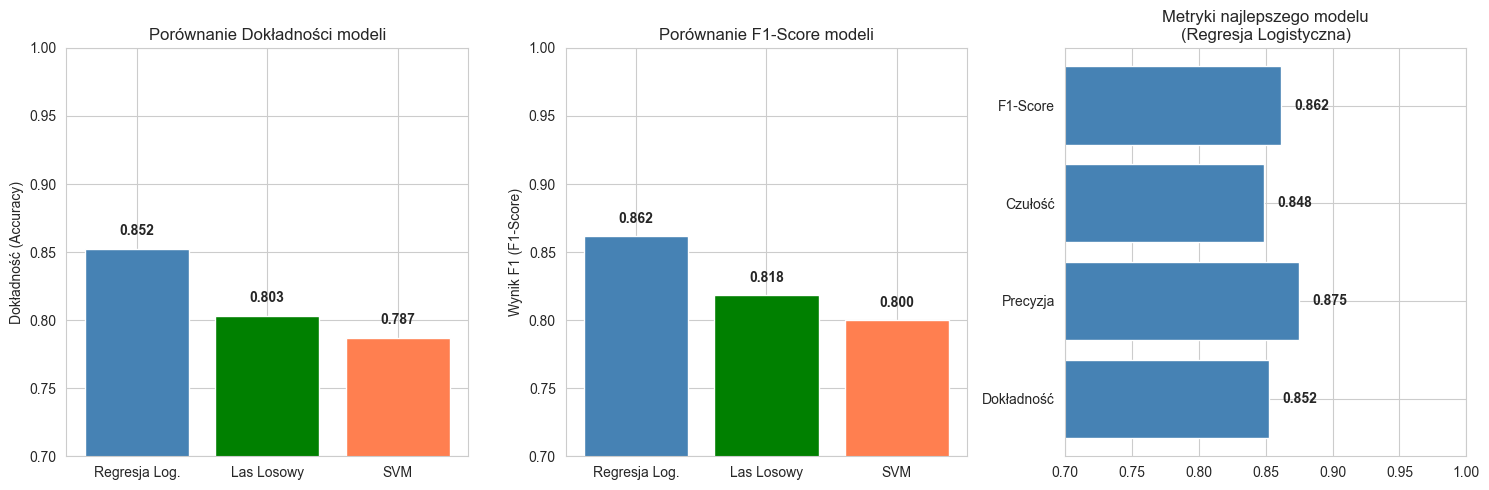

In [24]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

klucze = list(results.keys())
nazwy_modeli = []
for k in klucze:
    if 'Log' in k: nazwy_modeli.append('Regresja Log.')
    elif 'Random' in k: nazwy_modeli.append('Las Losowy')
    elif 'SVM' in k: nazwy_modeli.append('SVM')
    else: nazwy_modeli.append(k)

accuracies = [accuracy_score(y_test, results[m]) for m in klucze]
colors = ['steelblue', 'green', 'coral']

axes[0].bar(nazwy_modeli, accuracies, color=colors)
axes[0].set_ylabel('Dokładność (Accuracy)')
axes[0].set_title('Porównanie Dokładności modeli')
axes[0].set_ylim([0.7, 1.0])
for i, v in enumerate(accuracies):
    axes[0].text(i, v + 0.01, f'{v:.3f}', ha='center', fontweight='bold')

f1_scores = [f1_score(y_test, results[m]) for m in klucze]

axes[1].bar(nazwy_modeli, f1_scores, color=colors)
axes[1].set_ylabel('Wynik F1 (F1-Score)')
axes[1].set_title('Porównanie F1-Score modeli')
axes[1].set_ylim([0.7, 1.0])
for i, v in enumerate(f1_scores):
    axes[1].text(i, v + 0.01, f'{v:.3f}', ha='center', fontweight='bold')

try:
    winner_name = best_model_global
    winner_metrics = [best_metrics['acc'], best_metrics['prec'], best_metrics['rec'], best_metrics['f1']]
except NameError:
    winner_name = "Regresja Logistyczna"
    y_pred_log = results['Log Reg']
    winner_metrics = [
        accuracy_score(y_test, y_pred_log),
        precision_score(y_test, y_pred_log),
        recall_score(y_test, y_pred_log),
        f1_score(y_test, y_pred_log)
    ]

metrics_names = ['Dokładność', 'Precyzja', 'Czułość', 'F1-Score']

axes[2].barh(metrics_names, winner_metrics, color='steelblue')
axes[2].set_xlim([0.7, 1.0])
axes[2].set_title(f'Metryki najlepszego modelu\n({winner_name})')
for i, v in enumerate(winner_metrics):
    axes[2].text(v + 0.01, i, f'{v:.3f}', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

## 6.3. Wnioski z analizy

### Wniosek 1: Jakość danych
Zbiór danych Heart Disease UCI jest dobrze przygotowany:
- Brak brakujących wartości
- Zbalansowany rozkład klas (ok. 50/50)
- Zmienne mają sensowne wartości i rozkłady

### Wniosek 2: Najważniejsze cechy
Na podstawie analizy korelacji, najważniejsze cechy związane z występowaniem choroby serca to:
- **cp** (typ bólu w klatce piersiowej)
- **thalach** (maksymalne tętno)
- **exang** (dławica wysiłkowa)
- **oldpeak** (obniżenie ST)
- **ca** (liczba naczyń we fluoroskopii)

### Wniosek 3: Porównanie modeli
Wszystkie testowane modele osiągnęły dobre wyniki, jednak **Regresja Logistyczna okazała się najlepsza**.
- Regresja Logistyczna: najwyższy wynik F1-Score i Accuracy. Model ten świetnie sprawdza się w danych medycznych, gdzie zależności często są w przybliżeniu liniowe.
- Random Forest: wyniki na poziomie ~80%, optymalizacja poprawiła parametry, ale model ten (na tym konkretnym podziale danych) nie przebił prostszej regresji.
- SVM: wyniki zbliżone do pozostałych, ale czas treningu jest dłuższy (choć przy tak małym zbiorze pomijalny).

### Wniosek 4: Praktyczny wybór
Wybieramy Regresję Logistyczną jako model końcowy ze względu na:
- Najlepsze wyniki predykcyjne.
- Prostotę i łatwość interpretacji (współczynniki zmiennych mowią wprost o sile i kierunku wpływu).
- Szybkość działania.

### Wniosek 5: Ograniczenia
- Model był trenowany na ograniczonym zbiorze danych
- Wyniki mogą się różnić dla innych populacji
- Potrzebna walidacja na większych zbiorach danych